# Cross-Species Cancer Genomics Pipeline
## Dog vs Human Mammary Tumor Classification using Shared Orthologous Genes

**Research Question:** Can a classifier trained on human TCGA-BRCA breast cancer gene expression
correctly classify canine mammary tumor malignancy using shared orthologous genes?

**Datasets:**
- Human: TCGA-BRCA (1100 samples, PAM50 subtypes) via UCSC Xena
- Canine: Kim et al. 2020 / PRJNA489087 (154 canine mammary tumors)

**Pipeline steps:**
1. Download TCGA-BRCA (human)
2. Download canine mammary tumor data
3. Orthologous gene mapping via Ensembl BioMart
4. Preprocessing + batch normalisation
5. ML classification + ablation study

**Runtime:** ~45-90 mins total (mostly download time)

**Colab GPU:** Not required. CPU is sufficient.

In [1]:
# ============================================================
# CELL 0: Install all dependencies
# Run this cell first, then restart runtime if prompted
# ============================================================
!pip install pandas numpy requests tqdm scikit-learn xgboost matplotlib seaborn scipy -q
print('All packages installed.')

All packages installed.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# CELL 1: Create directory structure
# ============================================================
import os
for d in ['data/human','data/canine','data/aligned','outputs/figures']:
    os.makedirs(d, exist_ok=True)
print('Directories ready.')

Directories ready.


In [4]:
# ============================================================
# CELL 2: STEP 1 — Download TCGA-BRCA
# Downloads ~300MB. Takes 5-15 minutes depending on connection.
# ============================================================
%run 01_download_tcga_brca.py

Directories created.
  Already exists: data/human/TCGA_BRCA_expression.tsv.gz
  Already exists: data/human/TCGA_BRCA_clinical.tsv

Loading TCGA-BRCA expression matrix ...
  Shape (genes x samples): (20530, 1218)
  First 5 genes: ['ARHGEF10L', 'HIF3A', 'RNF17', 'RNF10', 'RNF11']
  First 3 sample IDs: ['TCGA-AR-A5QQ-01', 'TCGA-D8-A1JA-01', 'TCGA-BH-A0BQ-01']

Clinical metadata shape: (1247, 193)
Available columns (first 10): ['AJCC_Stage_nature2012', 'Age_at_Initial_Pathologic_Diagnosis_nature2012', 'CN_Clusters_nature2012', 'Converted_Stage_nature2012', 'Days_to_Date_of_Last_Contact_nature2012', 'Days_to_date_of_Death_nature2012', 'ER_Status_nature2012', 'Gender_nature2012', 'HER2_Final_Status_nature2012', 'Integrated_Clusters_no_exp__nature2012']
PAM50 subtypes extracted from clinical file.
subtype
LumA      434
LumB      194
Basal     142
Normal    119
Her2       67
Name: count, dtype: int64

Subtype labels saved.

Total samples: 1218
Tumor samples (suffix -01): 1097
Expression matrix

In [6]:
# ============================================================
# CELL 3: STEP 2 — Download Canine Mammary Tumor Data
# Option A: Figshare (pre-processed FPKM) — fast ~50MB
# Option B: If Figshare fails, manual GEO download instructions printed
# ============================================================
%run 02_download_canine.py

  Canine FPKM matrix (GEO GSE119810)
  Saved: data/canine/GSE119810_CMT_222S_FPKM.csv.gz

NOTE: If Option A download fails:
  1. Go to https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE119810
  2. Scroll to 'Supplementary file'
  3. Download: GSE119810_CMT_222S_FPKM.csv.gz
  4. Place it in: data/canine/GSE119810_CMT_222S_FPKM.csv.gz

Loading canine mammary tumor expression matrix ...
  Shape (genes x samples): (24580, 222)
  First 5 gene IDs: ['ENSCAFG00000000001', 'ENSCAFG00000000002', 'ENSCAFG00000000005', 'ENSCAFG00000000006', 'ENSCAFG00000000007']
  First 3 samples: ['CMT-002-tumor', 'CMT-003-tumor', 'CMT-008-normal']

Canine metadata shape: (222, 1)
Tumor/normal distribution:
malignancy
tumor     158
normal     64
Name: count, dtype: int64

Sample canine gene IDs:
['ENSCAFG00000000001', 'ENSCAFG00000000002', 'ENSCAFG00000000005', 'ENSCAFG00000000006', 'ENSCAFG00000000007', 'ENSCAFG00000000008', 'ENSCAFG00000000009', 'ENSCAFG00000000010', 'ENSCAFG00000000011', 'ENSCAFG000000000

In [30]:
# ============================================================
# CELL 4: STEP 3 — Orthologous Gene Mapping
# Queries Ensembl BioMart REST API (~3 min)
# Filters to one-to-one orthologs with >50% identity
# Aligns both matrices on shared genes
# ============================================================
%run 03_ortholog_mapping.py

Loading cached ortholog table ...
  Loaded: (7830, 7)

Raw ortholog table:
           dog_ensembl_id  dog_gene_symbol human_ensembl_id  \
47690  ENSCAFG00000032250              NaN  ENSG00000176294   
47834  ENSCAFG00000015460              NaN  ENSG00000182652   
47942  ENSCAFG00000023739              NaN  ENSG00000182652   
48018  ENSCAFG00000043265              NaN  ENSG00000258453   
48019  ENSCAFG00000043265              NaN  ENSG00000130538   

       human_gene_symbol     orthology_type  pct_id_dog_to_human  \
47690                NaN   ortholog_one2one              90.2280   
47834                NaN  ortholog_one2many              77.3913   
47942                NaN  ortholog_one2many              86.8339   
48018                NaN  ortholog_one2many              79.2049   
48019                NaN  ortholog_one2many              78.2875   

       pct_id_human_to_dog  
47690              90.2280  
47834              83.1776  
47942              86.2928  
48018              79

In [31]:
# ============================================================
# CELL 5: STEP 4 — Preprocessing
# - Aligns sample labels to expression matrices
# - Filters top 3000 genes by variance
# - Z-score normalisation per species
# - PCA visualisation saved to outputs/
# ============================================================
%run 04_preprocessing.py

Loading aligned expression matrices ...
  Human  (genes x samples): (4608, 1097)
  Canine (genes x samples): (4608, 222)

Human samples with subtype label: 1097 / 1097
PAM50 subtype distribution:
subtype
LumA      421
LumB      192
Basal     141
Her2       67
Normal     23
Name: count, dtype: int64

After removing 'Normal-like' and NaN: 844 samples

Canine samples with metadata: 222 / 222
Canine label distribution:
malignancy
tumor     158
normal     64
Name: count, dtype: int64

Gene variance filtering:
  Total shared genes: 4608
  Keeping top 3000 by variance in human data
  X_human shape: (844, 3000)
  X_canine shape: (222, 3000)

Applying per-gene z-score standardisation (batch normalisation) ...
  Human  mean: -0.0000, std: 1.0000
  Canine mean: -0.0000, std: 0.9972

Human label encoding: {'Basal': np.int64(0), 'Her2': np.int64(1), 'LumA': np.int64(2), 'LumB': np.int64(3), 'Normal': np.int64(4)}
Canine label encoding: {'normal': np.int64(0), 'tumor': np.int64(1)}

Saved: outputs/p

In [32]:
# ============================================================
# CELL 6: STEP 5 — ML Classification + Ablation
# Experiment A: Human 5-fold CV (baseline)
# Experiment B: Train human -> predict canine (main result)
# Experiment C: Ablation: gene set size comparison
# Saves 4 thesis-quality figures + results CSV
# ============================================================
%run 05_classification_ablation.py

Loading preprocessed data ...
X_human:  (844, 3000)  |  Classes: ['0', 'Basal', 'Her2', 'LumA', 'LumB', 'Normal']
X_canine: (222, 3000)  |  Classes: ['0', 'normal', 'tumor']

EXPERIMENT A: Within-human 5-fold cross-validation
  XGBoost: F1-macro = 0.7601 ± 0.0303
  Random Forest: F1-macro = 0.6649 ± 0.0154
  Logistic Regression: F1-macro = 0.8001 ± 0.0445

EXPERIMENT B: Train on human TCGA-BRCA, Predict on canine CMT

Human binary label distribution (0=non-aggressive, 1=aggressive):
1    488
0    356
Name: count, dtype: int64

  XGBoost:
    Accuracy:  0.4324
    F1-macro:  0.3376
    ROC-AUC:   0.3775
    Report:
              precision    recall  f1-score   support

      Normal       0.08      0.09      0.09        64
       Tumor       0.61      0.57      0.59       158

    accuracy                           0.43       222
   macro avg       0.34      0.33      0.34       222
weighted avg       0.46      0.43      0.44       222


  Random Forest:
    Accuracy:  0.4910
    F1-macr


--- outputs/figures\fig1_confusion_matrix.png ---


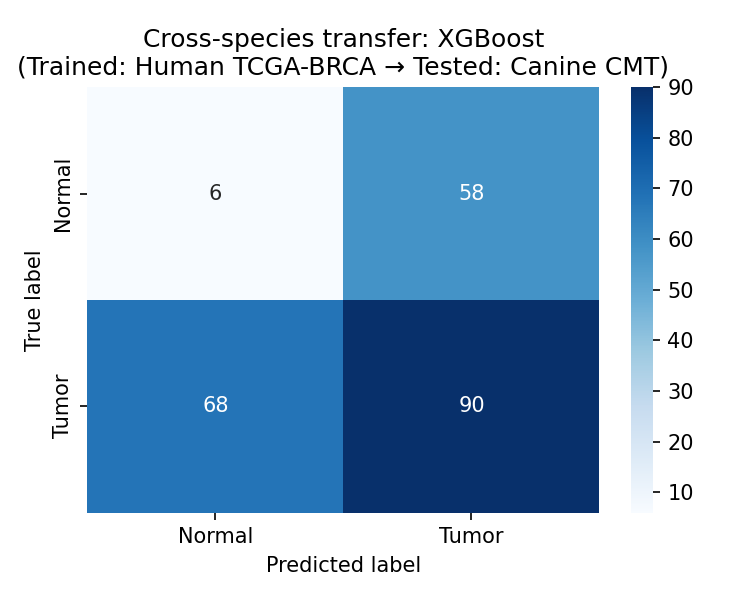


--- outputs/figures\fig2_ablation.png ---


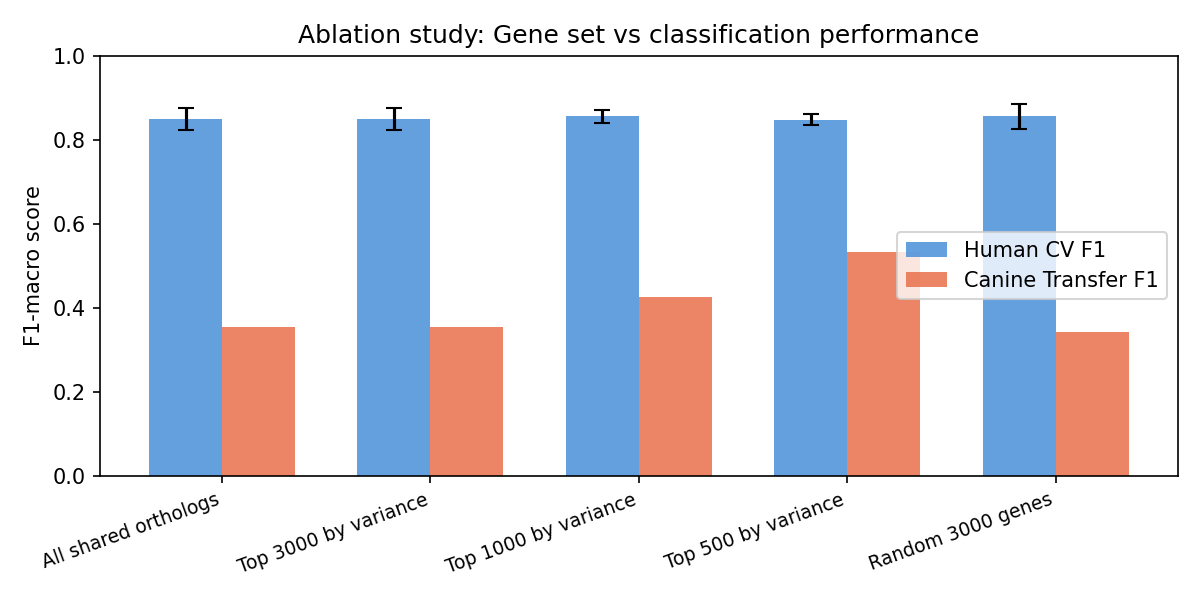


--- outputs/figures\fig3_feature_importance.png ---


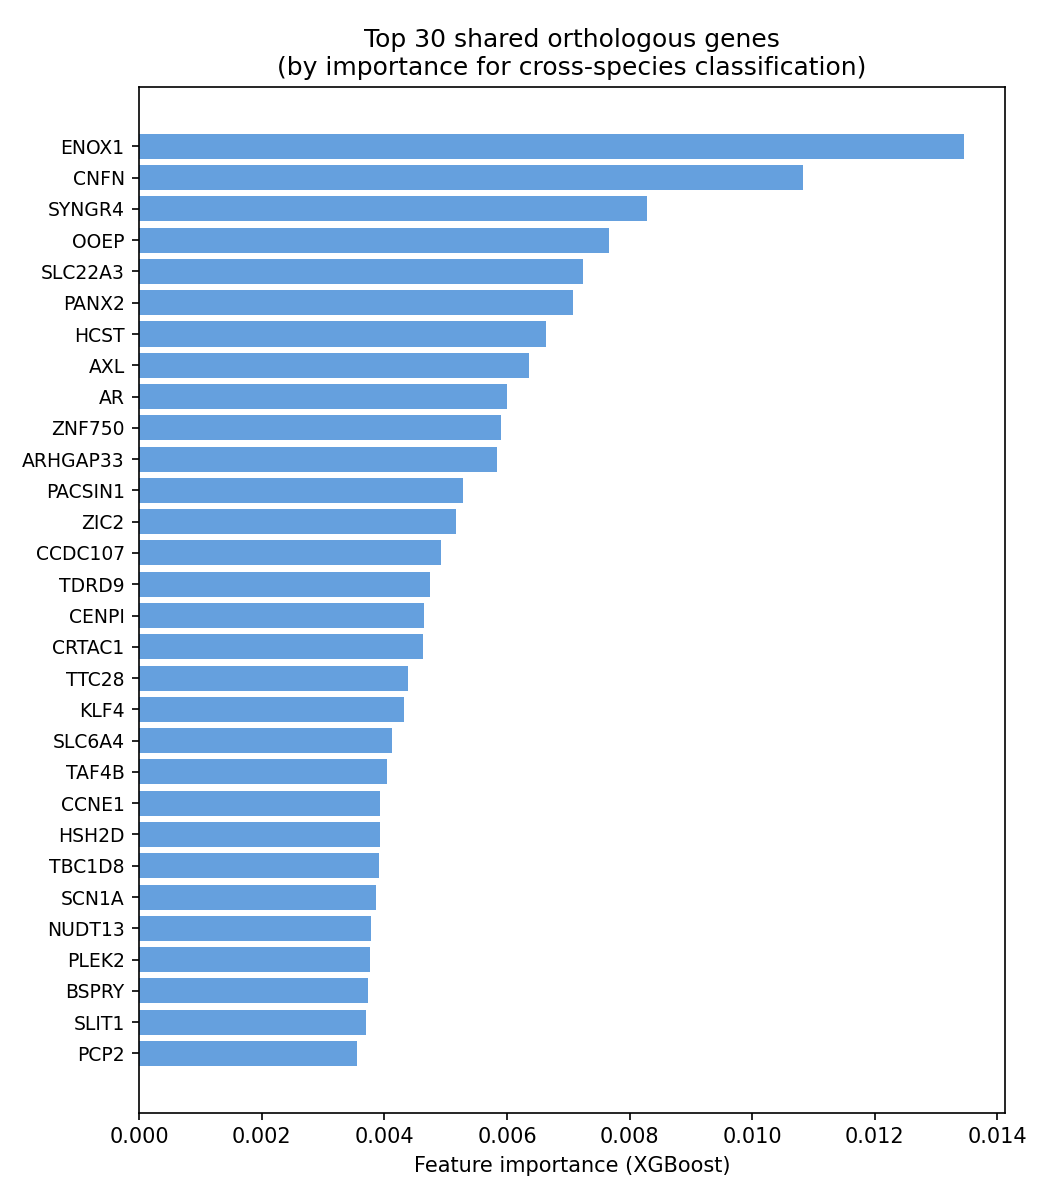


--- outputs/figures\fig4_model_comparison.png ---


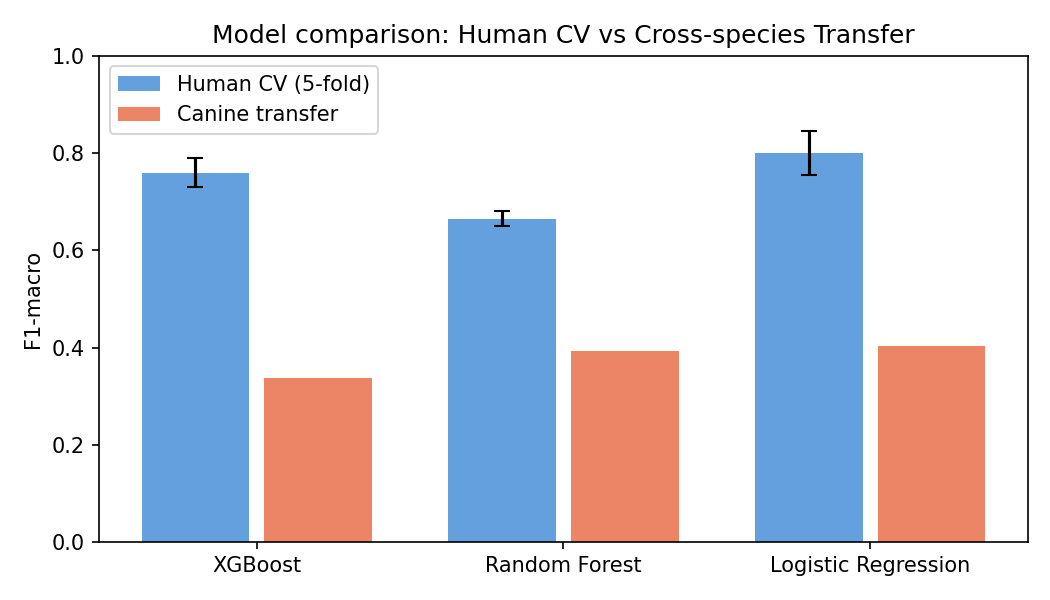

In [33]:
# ============================================================
# CELL 7: View all output figures inline
# ============================================================
from IPython.display import Image, display
import glob

figs = sorted(glob.glob('outputs/figures/*.png'))
for f in figs:
    print(f'\n--- {f} ---')
    display(Image(f))

In [34]:
# ============================================================
# CELL 8: Print final results summary
# ============================================================
import pandas as pd
summary = pd.read_csv('outputs/results_summary.csv')
print('=== FINAL RESULTS SUMMARY ===')
print(summary.to_string(index=False))

ablation = pd.read_csv('outputs/ablation_results.csv', index_col=0)
print('\n=== ABLATION STUDY RESULTS ===')
print(ablation.to_string())

=== FINAL RESULTS SUMMARY ===
              Model  Human CV F1 (mean)  Human CV F1 (std)  Canine Transfer F1  Canine Transfer AUC
            XGBoost              0.7601             0.0303              0.3376               0.3775
      Random Forest              0.6649             0.0154              0.3935               0.4418
Logistic Regression              0.8001             0.0445              0.4035               0.3155

=== ABLATION STUDY RESULTS ===
                      n_genes  human_cv_f1  human_cv_std  canine_transfer_f1
All shared orthologs   3000.0     0.849937      0.026809            0.353419
Top 3000 by variance   3000.0     0.849937      0.026809            0.353419
Top 1000 by variance   1000.0     0.856534      0.015023            0.426357
Top 500 by variance     500.0     0.848399      0.012542            0.532736
Random 3000 genes      3000.0     0.855969      0.030105            0.342819


## Output Files

| File | Description |
|---|---|
| `outputs/results_summary.csv` | Model comparison table (for paper Table 1) |
| `outputs/ablation_results.csv` | Ablation study table (for paper Table 2) |
| `outputs/figures/fig1_confusion_matrix.png` | Confusion matrix on canine data |
| `outputs/figures/fig2_ablation.png` | Gene set ablation bar chart |
| `outputs/figures/fig3_feature_importance.png` | Top 30 shared genes by importance |
| `outputs/figures/fig4_model_comparison.png` | Human CV vs canine transfer F1 |
| `outputs/pca_species_subtypes.png` | PCA: species separation check |
| `data/aligned/shared_ortholog_genes.csv` | Final gene list used in analysis |

## Citation

- Human data: TCGA Network (2012). Nature. doi:10.1038/nature11412
- Canine data: Kim et al. (2020). Nature Communications. doi:10.1038/s41467-020-17458-0
- Ortholog mapping: Ensembl BioMart (Cunningham et al. 2022)
- XGBoost: Chen & Guestrin (2016). KDD. doi:10.1145/2939672.2939785